In [145]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import pennylane as qp
from pennylane import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Note: see the project instructions for notations ($L$, $H_G$, etc.)

In [146]:
L = 3
N_PARAMS_PER_LAYER = 2
num_qubits = num_nodes = 6
dev = qp.device("default.qubit", wires=num_qubits)

### PQC

In [147]:
def data_encoding_circuit_block(ising_hamiltonian):
    qp.exp(ising_hamiltonian, coeff=1j)

def variational_layer(theta):
    for i in range(num_qubits):
        qp.RX(theta[0], wires=i)
        if len(theta) >= 2:
            qp.RY(theta[1], wires=i)
        if len(theta) >= 3:
            qp.RZ(theta[2], wires=i)

@qp.qnode(dev)
def pqc(theta_params, H_G):
    for j in range(L):
        data_encoding_circuit_block(H_G)
        variational_layer(theta_params[j])

    return qp.probs(wires=range(num_qubits))

### Metrics

In [148]:
def bce_loss(theta_params, H_G, y):
    probs = pqc(theta_params, H_G)
    prediction = probs[0]

    eps = 1e-15
    pred_clipped = qp.math.clip(prediction, eps, 1.0 - eps)

    return -(y * qp.math.log(pred_clipped) + (1 - y) * qp.math.log(1 - pred_clipped))

def cost_function(theta_params, dataset=None):
    losses = []

    for _, H_G, y in dataset:
        loss_value = bce_loss(theta_params, H_G, y)
        losses.append(loss_value)

    return qp.math.mean(qp.math.stack(losses))

def compute_accuracy(theta_params, dataset):
    correct_predictions = 0

    for _, H_G, y in dataset:
        probs = pqc(theta_params, H_G)
        prediction = probs[0]
        discrete_pred = 1 if prediction >= 0.5 else 0
        if discrete_pred == y:
            correct_predictions += 1

    return correct_predictions / len(dataset)

### Utils

In [149]:
def get_ising_hamiltonian(adj_matrix):
    """
    Returns the Ising Hamiltonian for a given adjacency matrix, as defined in the project instructions.
    If the graph has no edges, returns the zero Hamiltonian.
    """

    n = adj_matrix.shape[0]
    coeffs = []
    obs = []
    for i in range(n):
        for j in range(i + 1, n):
            if adj_matrix[i, j] == 1:
                coeffs.append(1.)
                obs.append(qp.PauliZ(i) @ qp.PauliZ(j))
    if len(obs) == 0:
        return qp.Hamiltonian([0.0], [qp.Identity(0)])
    return qp.Hamiltonian(coeffs, obs)

### Data Generation

In [151]:
N = 1000
dataset = []

num_nodes = num_qubits
threshold = np.log(num_nodes) / num_nodes   # The theoretical threshold for a graph to be connected is ln(n)/n
edge_probabilities = [random.uniform(threshold*0.9, threshold*1.5) for _ in range(N)]

connected_count = 0
disconnected_count = 0
for p in edge_probabilities:
    G = nx.erdos_renyi_graph(n=num_nodes, p=p)
    A = nx.to_numpy_array(G)
    H_G = get_ising_hamiltonian(A)
    if nx.is_connected(G):
        y = 0
        connected_count+=1
    else:
        y = 1
        disconnected_count+=1
    dataset.append((A, H_G, y))

print(f"The full dataset contains {connected_count} connected graphs and {disconnected_count} disconnected graphs.")
train_data, test_data = train_test_split(dataset, test_size=0.2, random_state=42)

The full dataset contains 496 connected graphs and 504 disconnected graphs.


### Training

In [152]:
epochs = 30

np.random.seed(42)
thetas = np.random.uniform(0, 2*np.pi, size=(L, N_PARAMS_PER_LAYER), requires_grad=True)

opt = qp.AdamOptimizer(stepsize=0.1)

history_train_loss = []
history_test_loss = []
history_train_acc = []
history_test_acc = []

print("Starting Training...")

for epoch in range(epochs):
    thetas = opt.step(cost_function, thetas, dataset=train_data)

    train_loss = cost_function(thetas, dataset=train_data)
    train_acc = compute_accuracy(thetas, dataset=train_data)

    test_loss = cost_function(thetas, dataset=test_data)
    test_acc = compute_accuracy(thetas, dataset=test_data)

    history_train_loss.append(train_loss)
    history_test_loss.append(test_loss)
    history_train_acc.append(train_acc)
    history_test_acc.append(test_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch + 1:3d} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f} | "
              f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}")

print("\nFinal Optimized Parameters (thetas):", thetas)

plt.figure(figsize=(12, 5))

# Plot 1: BCE Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), history_train_loss, label='Train Loss', marker='o', color='blue')
plt.plot(range(1, epochs + 1), history_test_loss, label='Test Loss', marker='x', linestyle='--', color='orange')
plt.title('Evolution of BCE Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# Plot 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), history_train_acc, label='Train Accuracy', marker='o', color='green')
plt.plot(range(1, epochs + 1), history_test_acc, label='Test Accuracy', marker='x', linestyle='--', color='red')
plt.title('Evolution of Classification Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0.0, 1.05) # Accuracy is strictly between 0 and 1
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

Starting Training...
Epoch   1 | Train Loss: 1.7684 | Train Acc: 0.51 | Test Loss: 1.8952 | Test Acc: 0.46
Epoch   5 | Train Loss: 1.5306 | Train Acc: 0.51 | Test Loss: 1.6542 | Test Acc: 0.46
Epoch  10 | Train Loss: 0.9570 | Train Acc: 0.52 | Test Loss: 1.0084 | Test Acc: 0.47


KeyboardInterrupt: 

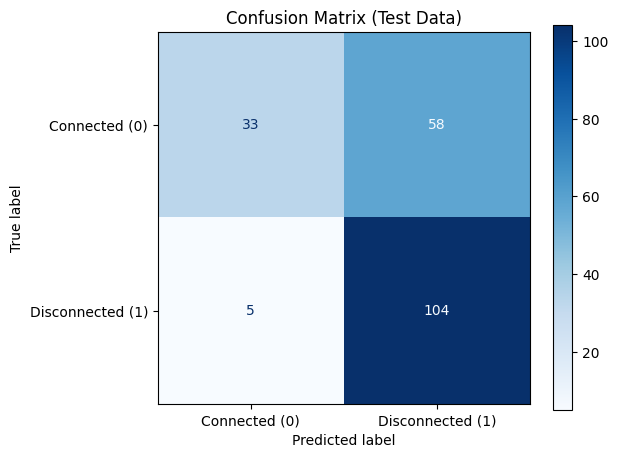

In [153]:
true_labels = []
predicted_labels = []

for A_i, H_i, y_i in test_data:
    true_labels.append(y_i)

    probs = pqc(thetas, H_i)
    prediction = probs[0]

    discrete_pred = 1 if prediction >= 0.5 else 0
    predicted_labels.append(discrete_pred)

cm = confusion_matrix(true_labels, predicted_labels, labels=[0, 1])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Connected (0)', 'Disconnected (1)']
)

disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix (Test Data)')
plt.show()